# Pattern pre-processing

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs
import pyxem as pxm
from skimage.exposure import rescale_intensity
from matplotlib.colors import LogNorm
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout, FloatSlider

plt.rcParams['figure.figsize'] = (3, 2)
plt.rcParams.update({'font.size': 8})
plt.rcParams['figure.dpi'] = 150

/Users/gvarnavides/Documents/git-repos/pattern-matching-paper/.venv/lib/python3.12/site-packages/hyperspy/misc/utils.py:72: VisibleDeprecationWarning: `_get_block_pattern` has moved to `hyperspy.misc.dask_utils`. It is for internal use only and may be removed in the future.
  warnings.warn(


In [2]:
folder_data = './data/'
s = hs.load(folder_data + '2xxx_selected_patterns.hspy')
tmds = hs.load(folder_data + '2xxx_selected_patterns_tmds.hspy')
signal_mask = hs.load(folder_data + 'signal_mask.hspy')
names = ['Al', r'$\theta^{\prime}_{001}$', r'$\theta^{\prime}_{100-1}$', r'$\theta^{\prime}_{100-2}$', r'T$_{1-1}$', r'T$_{1-2}$']

In [3]:
def threshold_and_rescale(s, th, disk_r):
    # Threshold the patterns and set all intensities below the threshold to zero
    sts = s.data.copy()
    sts = pxm.signals.ElectronDiffraction2D(sts)
    sts.data[sts.data < th] = 0.
    
    # Rescale intensity and change dtype
    smax, smin = np.max(sts.data), np.min(sts.data)
    sts.map(rescale_intensity, in_range=(smin, smax), out_range=(0, 255), show_progressbar=False, inplace=True)
    sts.change_dtype(np.uint8)

    return sts

In [4]:
i = 8
disk_rs = np.arange(1, 5.25, 0.25)
dr = disk_rs[i]
tmds_i = tmds.inav[:, i]

th = 0.3
sts = threshold_and_rescale(tmds_i, th, dr)

interactive(children=(Dropdown(description='disk radius:', index=8, layout=Layout(width='200px'), options=(np.…

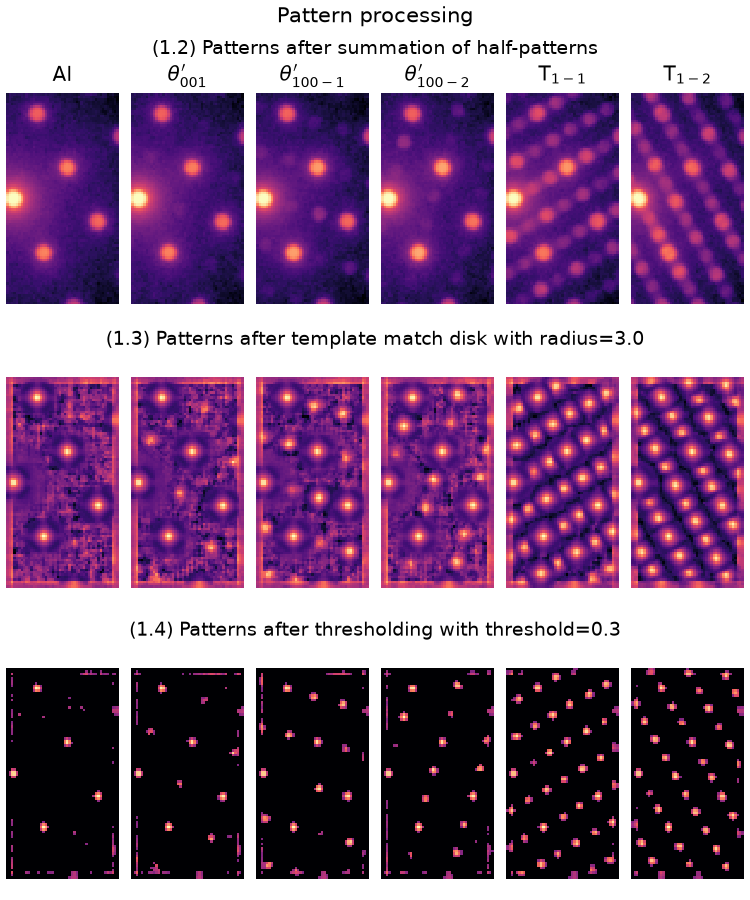

In [5]:
# | label: app:preprocessing_widget
fig = plt.figure(layout='constrained', figsize=(5, 6))

subfigs = fig.subfigures(3, 1, wspace=0.0, height_ratios=[1, 1, 1])
fig.suptitle('Pattern processing', fontsize=10)

cmap_p = 'magma'

axs = subfigs[0].subplots(1, 6)
p_axs = []
for ax, p, n in zip(axs, s, names):
    ax.axis('off')
    p_axs.append(ax.imshow(p.data, cmap=cmap_p, interpolation='none', norm=LogNorm(vmin=p.data.min(), vmax=p.data.max())))
    ax.set_title(n)
subfigs[0].suptitle('(1.2) Patterns after summation of half-patterns', fontsize=9)

axs1 = subfigs[1].subplots(1, 6)
t_axs = []
for ax1, t in zip(axs1, tmds_i):
    ax1.axis('off')
    t_axs.append(ax1.imshow(t.data, cmap=cmap_p, interpolation='none'))
subfigs[1].suptitle('(1.3) Patterns after template match disk with radius=' + str(dr), fontsize=9)

axs2 = subfigs[2].subplots(1, 6)
s_axs = []
for ax2, st in zip(axs2, sts):
    ax2.axis('off')
    s_axs.append(ax2.imshow(st.data, cmap=cmap_p, interpolation='none'))
subfigs[2].suptitle('(1.4) Patterns after thresholding with threshold=' + str(round(th, 2)), fontsize=9)

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'


def update_plots(dr, th):
    i = int(np.where(disk_rs == dr)[0][0])
    tmds_i = tmds.inav[:, i]
    for t_ax, t in zip(t_axs, tmds_i):
        t_ax.set_data(t.data)
        t_ax.set_clim([np.min(t.data), np.max(t.data)])
    subfigs[1].suptitle('(1.3) Patterns after template match disk with radius=' + str(dr), fontsize=9)
    
    sts = threshold_and_rescale(tmds_i, th, dr)
    for s_ax, st in zip(s_axs, sts):
        disk_r = int(dr)
        s_ax.set_data(st.data)
        s_ax.set_clim([np.min(st.data), np.max(st.data)])
    subfigs[2].suptitle('(1.4) Patterns after thresholding with threshold=' + str(round(th, 2)), fontsize=9)
    fig.canvas.draw_idle()

    return None


disk_r_widget = Dropdown(options=disk_rs, index=i, description='disk radius:', 
                         layout=Layout(width='200px'), style={'description_width': '100px'}, disabled=False)
th_slider = FloatSlider(value=th, min=-0.9, max=0.9, step=0.05, description='threshold: ', continuous_update=True, 
                        layout=Layout(width='350px'), style={'description_width': '100px'}, disabled=False)
wid = interactive(update_plots, dr=disk_r_widget, th=th_slider)
display(wid)